# 2. 평가 — 그림 + 통계치 저장

`result/predictions/*.csv` 를 로드해 지표를 계산하고,
- **통계치** → `result/statistics/metrics.csv`, `stage_r2.csv`
- **그림** → `result/image/metric_bars.png`, `scatter_grid.png`, `stage_r2.png`

**지표**: R²(설명력), MAE/RMSE(오차, 작을수록↑), Spearman ρ(순위 일치도, 높을수록↑ — 상대가치 랭킹).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from util import file_manager as fm, plot
from util.metric import metrics, stage_r2

preds = {p.stem: pd.read_csv(p) for p in fm.list_predictions()}
print("loaded predictions:", list(preds.keys()))

loaded predictions: ['bench_catboost', 'bench_gbm', 'bench_lgbm', 'bench_ridge', 'bench_xgboost', 'deeponet_curve_direct', 'deeponet_curve_hybrid', 'deeponet_direct', 'deeponet_hybrid', 'pi_deeponet_hybrid']


In [2]:
# 지표 표
rows, scat = [], {}
for name, df in preds.items():
    rows.append({"model": name, **metrics(df["y_true"], df["y_pred"])})
    scat[name] = (df["y_true"].values, df["y_pred"].values)
mt = pd.DataFrame(rows).set_index("model").sort_values("R2", ascending=False)
mt.to_csv(fm.stat("metrics"))
print(mt.round(4).to_string())

                           R2     MAE    RMSE  Spearman
model                                                  
deeponet_hybrid        0.7274  0.0210  0.0270    0.8642
pi_deeponet_hybrid     0.7239  0.0213  0.0272    0.8664
deeponet_curve_hybrid  0.7210  0.0210  0.0273    0.8582
bench_ridge            0.5608  0.0269  0.0343    0.7619
bench_xgboost          0.3196  0.0352  0.0427    0.5389
bench_catboost         0.3155  0.0357  0.0428    0.5320
bench_lgbm             0.3109  0.0353  0.0430    0.5403
bench_gbm              0.2569  0.0371  0.0446    0.5037
deeponet_curve_direct  0.0558  0.0394  0.0503    0.4332
deeponet_direct       -0.2389  0.0493  0.0576   -0.0473


In [3]:
# stage별 R² (하이브리드)
st = {name: stage_r2(df) for name, df in preds.items() if stage_r2(df) is not None}
sdf = pd.DataFrame(st).T
sdf.to_csv(fm.stat("stage_r2"))
print(sdf.round(3).to_string())

                       stage1_MC_R2  stage2_resid_R2  final_FAIR_R2
deeponet_curve_hybrid         0.945            0.487          0.721
deeponet_hybrid               0.964            0.487          0.727
pi_deeponet_hybrid            0.917            0.487          0.724


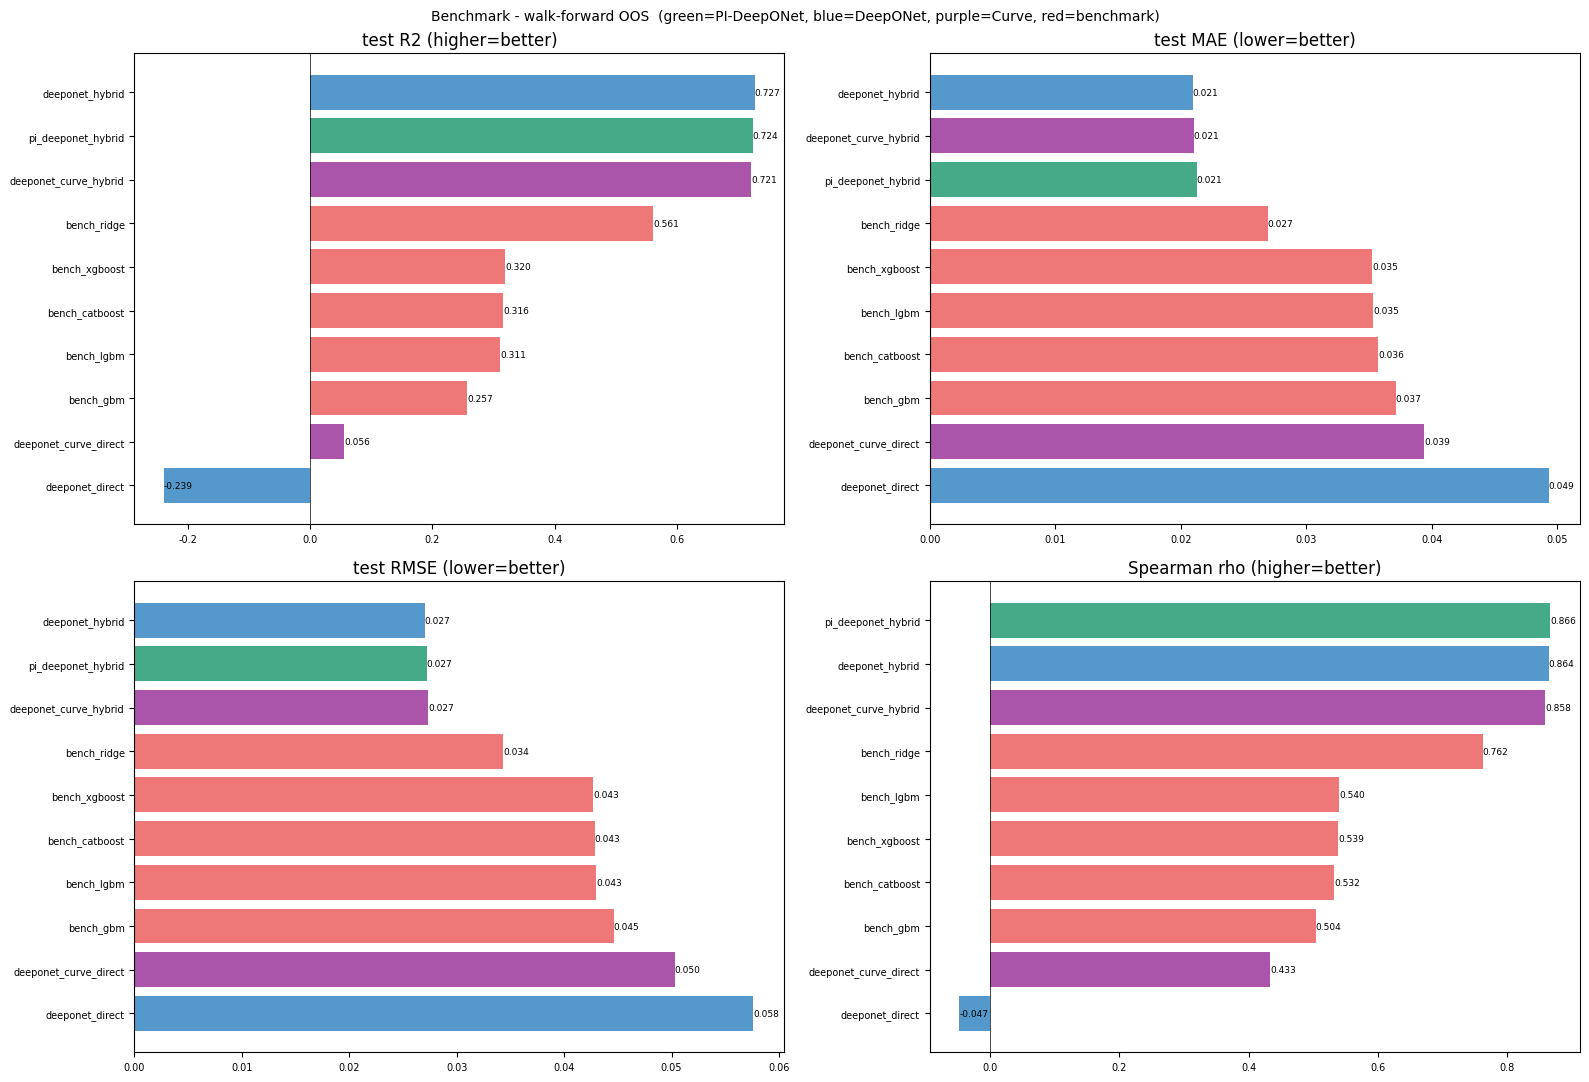

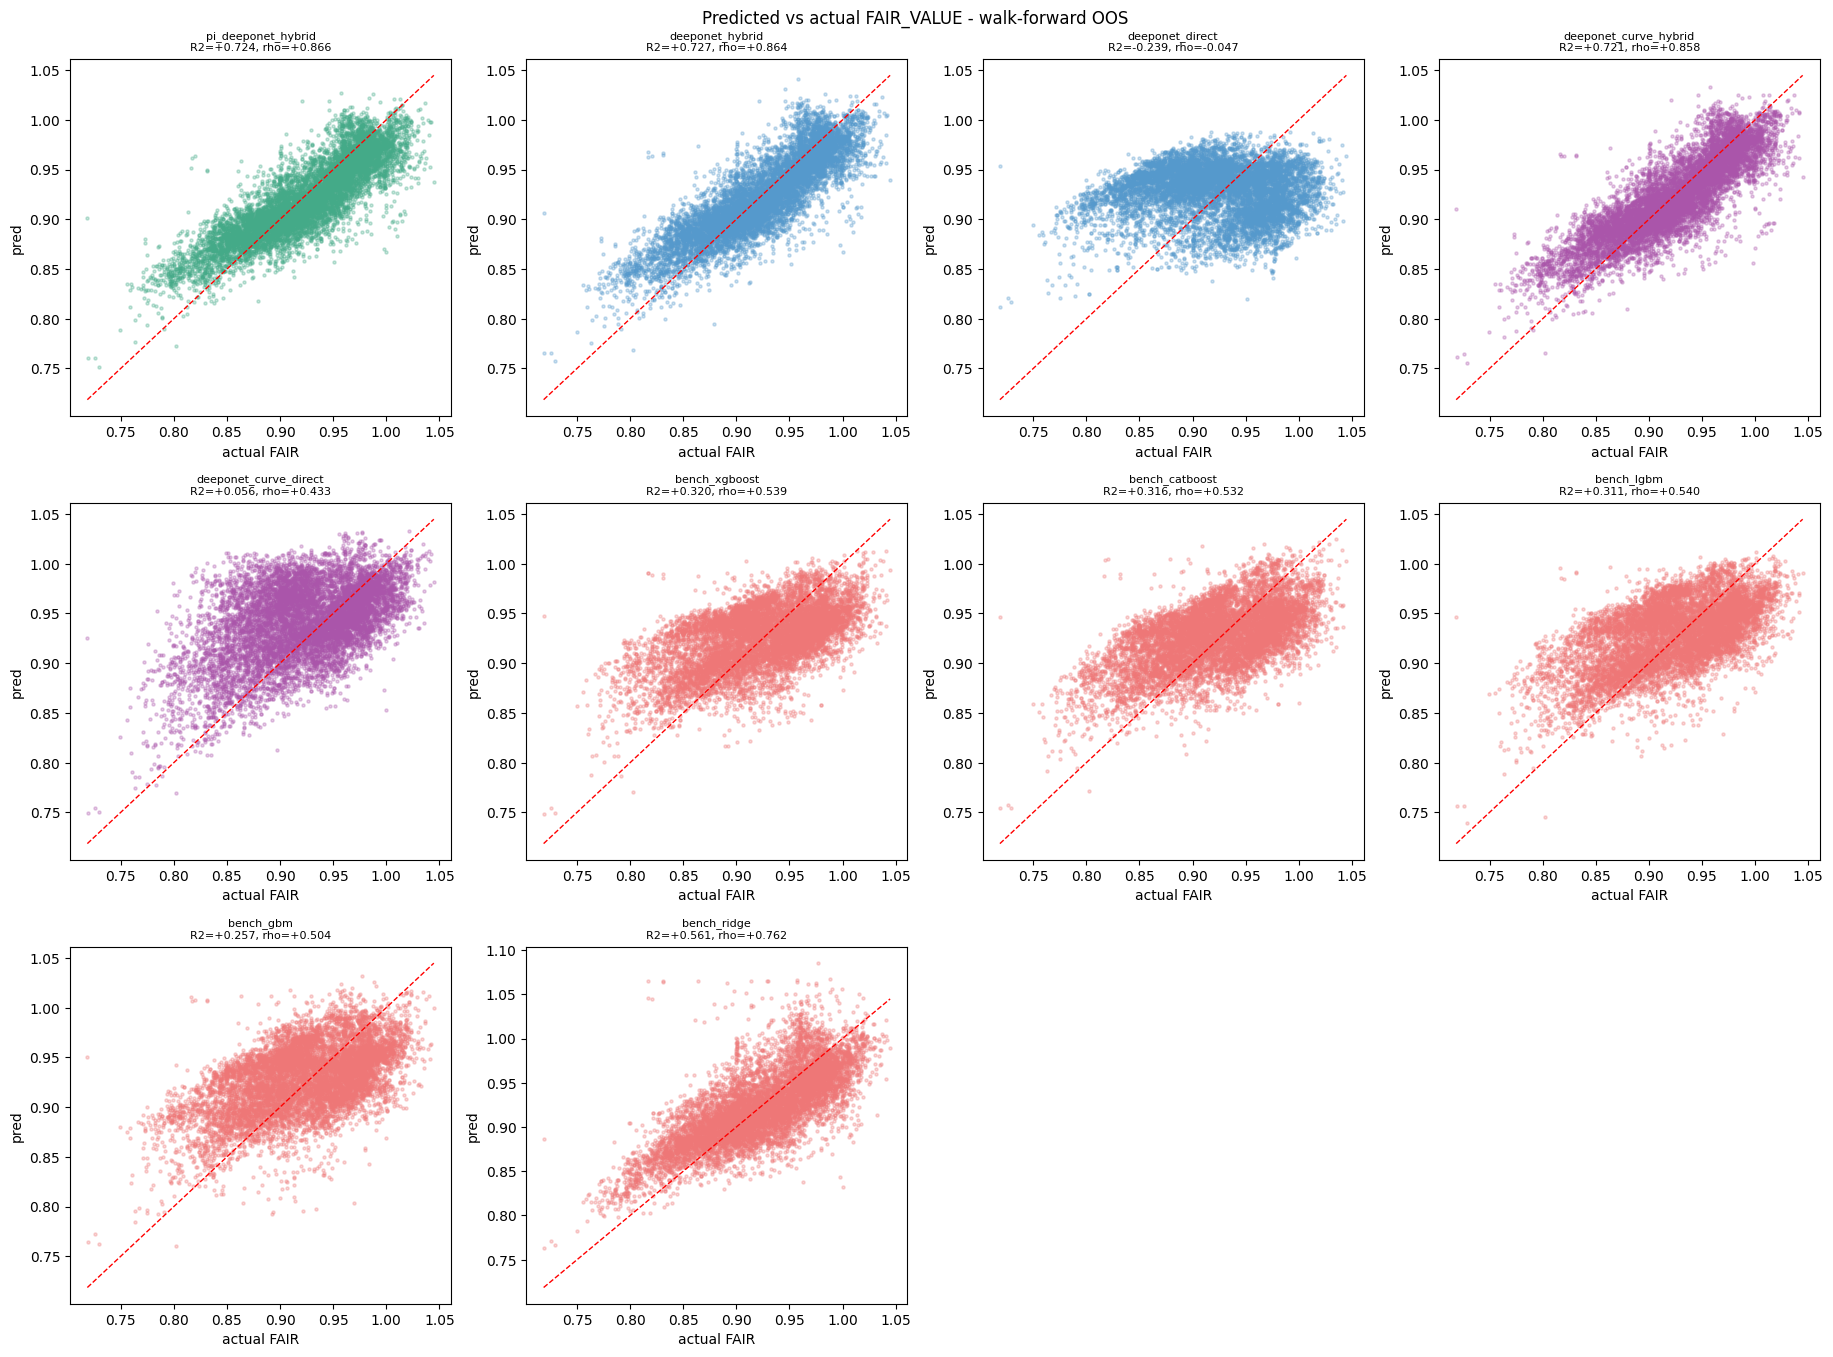

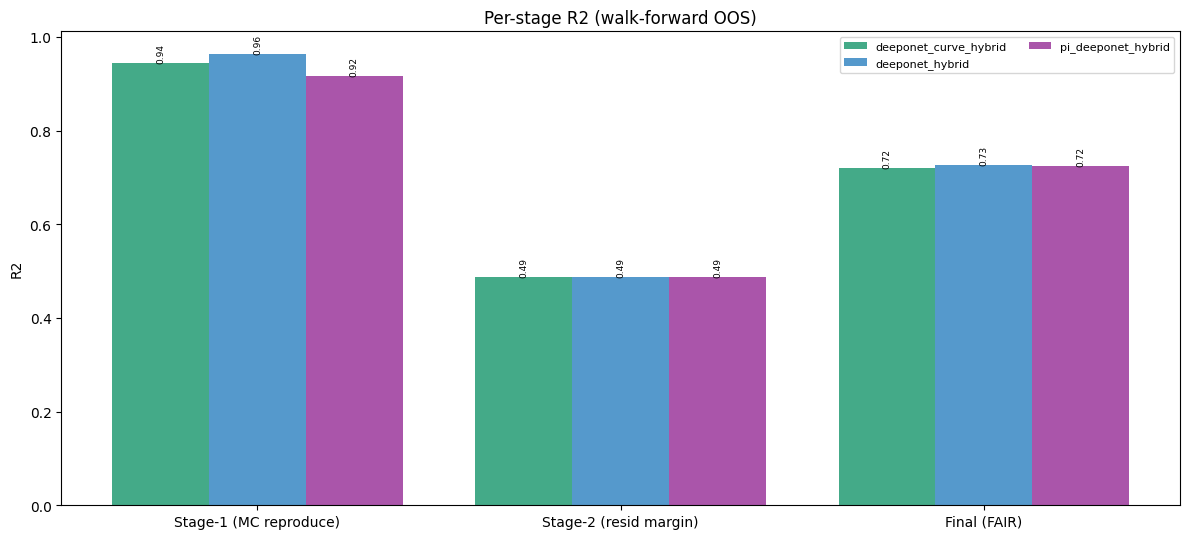

saved images -> ['metric_bars.png', 'scatter_grid.png', 'stage_r2.png']
saved stats  -> ['metrics.csv', 'stage_r2.csv']


In [ ]:
# 그림 저장 + 표시
ORDER = [
    "pi_deeponet_hybrid",
    "deeponet_hybrid",
    "deeponet_direct",
    "deeponet_curve_hybrid",
    "deeponet_curve_direct",
    "bench_xgboost",
    "bench_catboost",
    "bench_lgbm",
    "bench_gbm",
    "bench_ridge",
]
order = [m for m in ORDER if m in scat] + [m for m in scat if m not in ORDER]

plot.metric_bars(mt, fm.image("metric_bars"))
plot.scatter_grid(scat, order=order, path=fm.image("scatter_grid"))
if len(sdf):
    plot.stage_r2_bar(sdf, fm.image("stage_r2"))
plt.show()
print("saved images ->", [p.name for p in sorted(fm.IMAGE.glob("*.png"))])
print("saved stats  ->", [p.name for p in sorted(fm.STAT.glob("*.csv"))])